In [1]:
rm(list=ls())

In [2]:
install.packages("ggplot2", dependencies=TRUE)
install.packages("readxl", dependencies=TRUE)
install.packages("corrplot", dependencies=TRUE)


Installing package into ‘/home/guest/R/x86_64-pc-linux-gnu-library/4.2’
(as ‘lib’ is unspecified)

also installing the dependencies ‘yaml’, ‘systemfonts’, ‘gtable’, ‘rlang’, ‘S7’, ‘scales’, ‘vctrs’, ‘ggplot2movies’, ‘quarto’, ‘ragg’, ‘svglite’, ‘vdiffr’


Warning message in install.packages("ggplot2", dependencies = TRUE):
“installation of package ‘systemfonts’ had non-zero exit status”
Warning message in install.packages("ggplot2", dependencies = TRUE):
“installation of package ‘quarto’ had non-zero exit status”
Warning message in install.packages("ggplot2", dependencies = TRUE):
“installation of package ‘ragg’ had non-zero exit status”
Warning message in install.packages("ggplot2", dependencies = TRUE):
“installation of package ‘svglite’ had non-zero exit status”
Installing package into ‘/home/guest/R/x86_64-pc-linux-gnu-library/4.2’
(as ‘lib’ is unspecified)

Installing package into ‘/home/guest/R/x86_64-pc-linux-gnu-library/4.2’
(as ‘lib’ is unspecified)

also installing the depend

In [4]:
library(readxl)
exchanges<-read_excel("exchanges.xlsx")

In [5]:
head(exchanges)

Date,btc_coinbase,btc_kraken,btc_bitstamp,btc_itbit,btc_bitfinex,btc_hitbtc,btc_gemini,btc_bittrex,usdyuan,usdeur,gold,oil,sp500
<dttm>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2016-05-18,455.56,454.2201,454.2201,454.0001,453.51,457.19,454.27,462.0,6.5386,0.8864,1258.55,48.19,2047.63
2016-05-19,438.38,440.3771,443.1800,443.4501,435.00,444.08,440.01,455.0,6.5495,0.8922,1254.70,48.16,2040.04
2016-05-20,445.65,433.5001,440.9101,441.8901,441.57,440.66,442.99,430.0,6.5490,0.8910,1252.15,47.75,2052.32
2016-05-21,446.28,438.5401,443.4101,443.0001,440.81,441.59,443.21,424.5,6.5490,0.8910,1252.15,47.75,2052.32
2016-05-22,442.48,438.3400,439.6200,438.6100,437.48,436.36,437.57,423.3,6.5490,0.8910,1252.15,47.75,2052.32
2016-05-23,445.67,441.8610,442.3000,442.7901,443.66,443.97,443.99,423.3,6.5557,0.8926,1249.12,48.08,2048.04


In [6]:
data <- exchanges

In [7]:
data1<-data[-1]

In [8]:
data2<-as.data.frame(sapply(data1,function(x)diff(log(x),lag=1)))

In [9]:
attach(data2)

### Frequentist Analysis


Call:
lm(formula = btc_coinbase ~ ., data = data2)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.052330 -0.003256  0.000023  0.002987  0.052098 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)   0.0001059  0.0003123   0.339  0.73454    
btc_kraken    0.0210321  0.0123977   1.696  0.09025 .  
btc_bitstamp  0.0384385  0.0359272   1.070  0.28503    
btc_itbit     0.0130343  0.0256007   0.509  0.61082    
btc_bitfinex  0.2297741  0.0315236   7.289 8.47e-13 ***
btc_hitbtc    0.0821093  0.0184755   4.444 1.03e-05 ***
btc_gemini    0.5981632  0.0308680  19.378  < 2e-16 ***
btc_bittrex   0.0056419  0.0145595   0.388  0.69850    
usdyuan      -0.1045943  0.2066436  -0.506  0.61291    
usdeur        0.2060414  0.0986501   2.089  0.03710 *  
gold          0.0712161  0.0575053   1.238  0.21597    
oil          -0.0595675  0.0192726  -3.091  0.00208 ** 
sp500        -0.0952889  0.0569865  -1.672  0.09495 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘

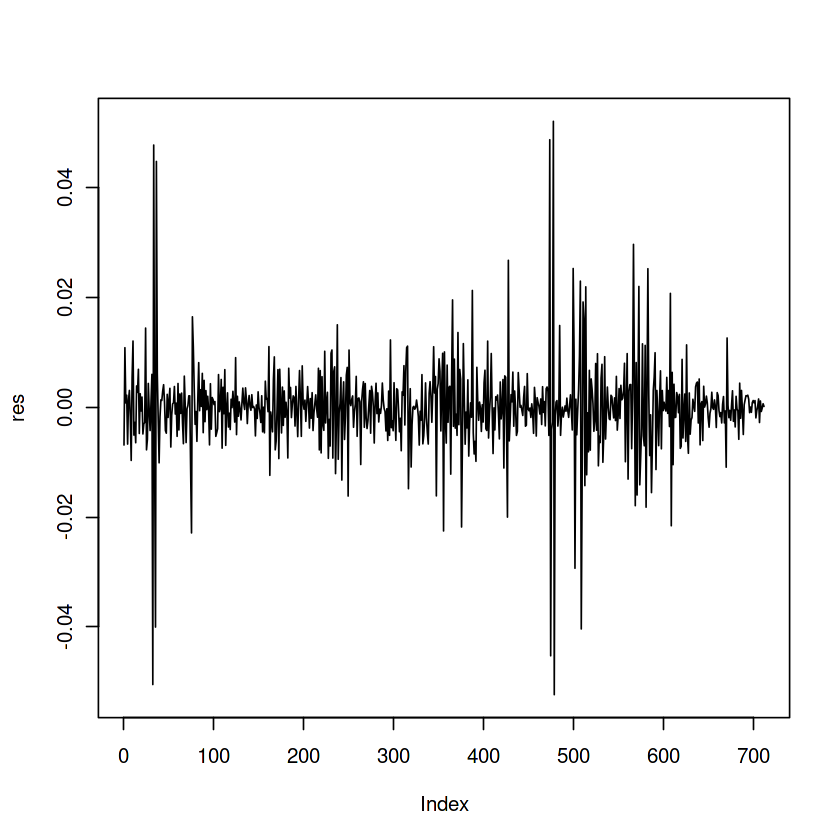

In [12]:
model_3<-lm(btc_coinbase~.,data=data2)
summary(model_3)
# Get and plot residuals
res<-model_3$residuals
plot(res,type='l')

### Bayesian Analysis

In [15]:
install.packages("rstanarm")
library(rstanarm)
model_b<-stan_glm(btc_coinbase~.,data=data2)
summary(model_b, digits=3)
# Get and plot residuals
resb<-model_b$residuals
plot(resb,type="l")

Installing package into ‘/home/guest/R/x86_64-pc-linux-gnu-library/4.2’
(as ‘lib’ is unspecified)

Loading required package: Rcpp



ERROR: Error: package or namespace load failed for ‘rstanarm’ in loadNamespace(i, c(lib.loc, .libPaths()), versionCheck = vI[[i]]):
 namespace ‘rlang’ 1.0.6 is already loaded, but >= 1.1.0 is required
